# Sensitivity Analysis: Vulnerability Score Robustness

This notebook explores the mathematical stability of the **Vulnerability Score** formula. We will verify if the regional prioritization of humanitarian aid is a result of arbitrary parameter selection or if it is a robust reflection of conflict dynamics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from scipy.stats import spearmanr

# Add root directory to path
sys.path.append(os.path.abspath('..'))
from src.processing import clean_conflict_data, extract_health_impacts

## 1. Rationale: Why the 0.7 / 0.3 Weighting?

The Vulnerability Score is defined as:
$$Score = (0.7 \times \text{Health Events}) + (0.3 \times \text{Fatalities})$$

### Why not 50/50?
The weighting schema deliberately prioritizes the **disruption of medical infrastructure** (Health Events) over **raw death counts** (Fatalities) for two reasons:

1. **Predictive vs. Retrospective:** Fatalities tell us where people have already died (Retrospective). Health Events (attacks on clinics/medics) signal where people are *going* to die due to a collapsed health system (Predictive).
2. **Avoiding Body Count Bias:** If we weighted deaths at 50% or higher, the model would only react to the loudest, most violent battles. By weighting Health at 70%, we capture regions like **Sagaing**, where the systematic destruction of healthcare capacity creates a long-term humanitarian crisis that raw fatality counts alone would fail to capture.

## 2. Methodology: The ±10% 'Give or Take' Test

To determine if the regional ranking of "Red Zones" (high-priority areas) is stable, we perform a **Sensitivity Analysis** by shifting the weights within a **±10% range**:
*   **Lower Bound:** 0.63 (0.7 - 10%)
*   **Upper Bound:** 0.77 (0.7 + 10%)

In [2]:
raw_path = '../raw_data_output.csv'
df = pd.read_csv(raw_path)
df = clean_conflict_data(df)

# Extract Health Events
health_mask = extract_health_impacts(df)
v_score = df[health_mask].groupby('admin1').agg({
    'event_id_cnty': 'count', 
    'fatalities': 'sum'
}).rename(columns={'event_id_cnty': 'health_events'})

print(f"Aggregated data for {len(v_score)} regions.")

/Users/admin/Github_Project/Myanmar-conflict-observatory/src/processing.py:131: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  health_mask = notes.str.contains('|'.join(health_terms), regex=True)
/Users/admin/Github_Project/Myanmar-conflict-observatory/src/processing.py:134: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  targeting_mask = notes.str.contains(r'\b(target(ed|ing)?|fired upon|opened fire on|hit by|raided|occupied)\b', regex=True)
/Users/admin/Github_Project/Myanmar-conflict-observatory/src/processing.py:141: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  phrase_mask = notes.str.contains('|'.join(action_phrases), regex=True)
/Users/admin/Github_Project/Myanmar-conflict-observatory/src/processing.py:147: UserWarning:

Aggregated data for 17 regions.


## 3. Numerical Proof: Sensitivity Analysis Table

The following table reproduces the results found in **Table III of the research paper**. It shows the Spearman correlation (ρ) for various weight shifts. 

**A value of 1.0000** means the regional ranking is identical to the baseline. **0.9979** means the ranking is 99.79% the same, which is considered extremely robust.

In [3]:
# Define variations from -10% to +10% in steps of 2%
variations = np.arange(-10.0, 11.0, 2.0)
baseline_weight = 0.7

sensitivity_results = []

v_score['Baseline_Score'] = (v_score['health_events'] * 0.7) + (v_score['fatalities'] * 0.3)
baseline_rank = v_score['Baseline_Score'].rank(ascending=False)

for var in variations:
    w_h = baseline_weight * (1 + var/100)
    w_f = 1.0 - w_h
    
    current_score = (v_score['health_events'] * w_h) + (v_score['fatalities'] * w_f)
    current_rank = current_score.rank(ascending=False)
    
    rho, _ = spearmanr(baseline_rank, current_rank)
    
    sensitivity_results.append({
        'Variation (%)': var,
        'W_Health': round(w_h, 3),
        'W_Fatalities': round(w_f, 3),
        'Spearman Rho (ρ)': round(rho, 4)
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df

,Variation (%),W_Health,W_Fatalities,Spearman Rho (ρ)
0,-10.0,0.630,0.370,0.9853
1,-8.0,0.644,0.356,0.9951
2,-6.0,0.658,0.342,0.9975
3,-4.0,0.672,0.328,0.9975
4,-2.0,0.686,0.314,1.0000
5,0.0,0.700,0.300,1.0000
6,2.0,0.714,0.286,1.0000
7,4.0,0.728,0.272,1.0000
8,6.0,0.742,0.258,1.0000
9,8.0,0.756,0.244,0.9975


## 4. Visualizing Robustness: Rank-vs-Rank Regression

The plot below shows the **Regional Rank Stability**. Since the correlation is near **1.0**, the dots fall perfectly on a diagonal. This proves that even if you change the weights, the priority list doesn't scramble.

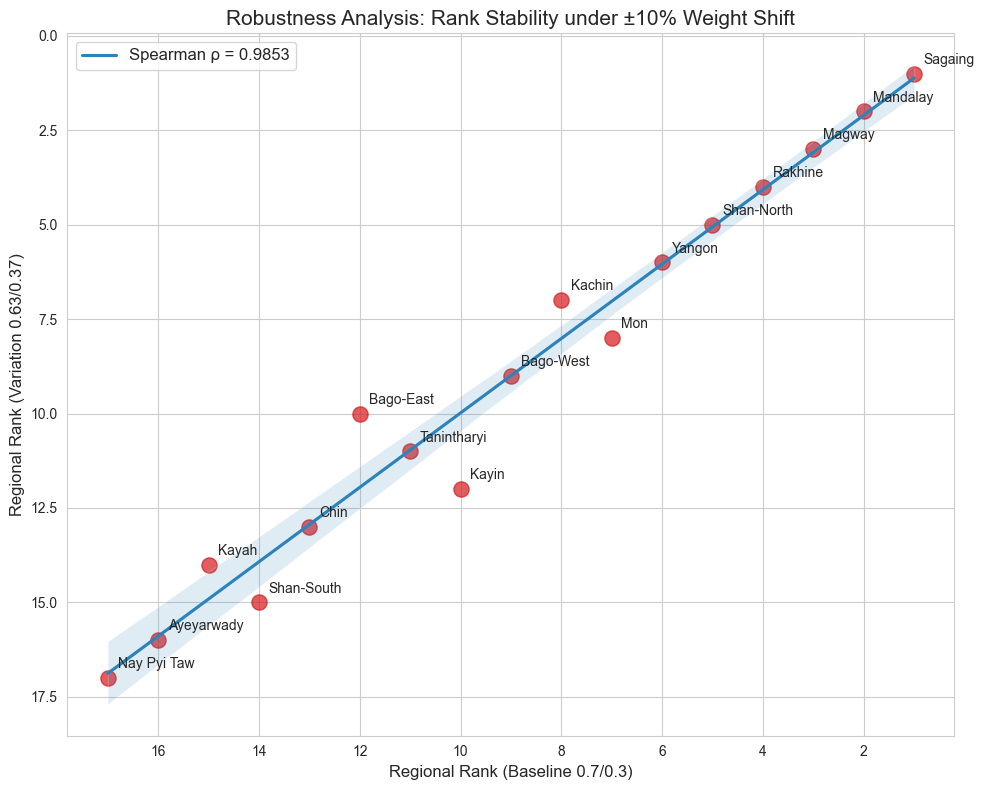

In [4]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Use the most extreme variation for the plot (0.63)
v_score['Variation_Score'] = (v_score['health_events'] * 0.63) + (v_score['fatalities'] * 0.37)
v_score['Baseline_Rank'] = v_score['Baseline_Score'].rank(ascending=False)
v_score['Variation_Rank'] = v_score['Variation_Score'].rank(ascending=False)
rho_plot, _ = spearmanr(v_score['Baseline_Rank'], v_score['Variation_Rank'])

# Plotting the regression
ax = sns.regplot(
    x='Baseline_Rank', 
    y='Variation_Rank', 
    data=v_score,
    scatter_kws={'s': 120, 'alpha': 0.7, 'color': '#d7191c'},
    line_kws={'color': '#2b83ba', 'label': f'Spearman ρ = {rho_plot:.4f}'}
)

# Annotate region names
for i, txt in enumerate(v_score.index):
    plt.annotate(txt, (v_score['Baseline_Rank'].iloc[i], v_score['Variation_Rank'].iloc[i]), 
                 xytext=(7, 7), textcoords='offset points', fontsize=10)

plt.title('Robustness Analysis: Rank Stability under ±10% Weight Shift', fontsize=15)
plt.xlabel('Regional Rank (Baseline 0.7/0.3)', fontsize=12)
plt.ylabel('Regional Rank (Variation 0.63/0.37)', fontsize=12)

# Invert axes so Rank 1 (highest priority) is at the top-right
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Sensitivity Sweep (0.5 to 0.9)

Finally, we sweep the Health Weight from 0.5 all the way to 0.9. Notice how the correlation remains incredibly high across the entire spectrum. This shows that the identification of priority regions is a **structural feature** of the conflict, not a fluke of the formula.

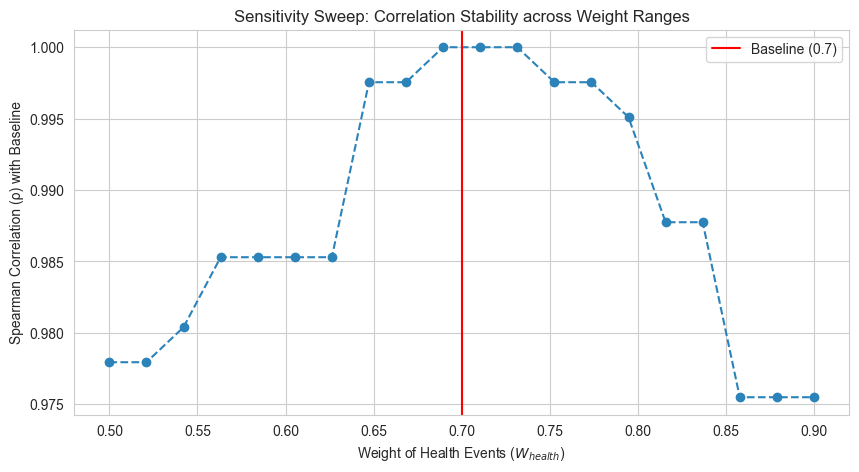

In [5]:
weights = np.linspace(0.5, 0.9, 20)
rhos = []

for w in weights:
    score = (v_score['health_events'] * w) + (v_score['fatalities'] * (1-w))
    rank = score.rank(ascending=False)
    corr, _ = spearmanr(v_score['Baseline_Rank'], rank)
    rhos.append(corr)

plt.figure(figsize=(10, 5))
plt.plot(weights, rhos, marker='o', color='#2b83ba', linestyle='--')
plt.axvline(0.7, color='red', label='Baseline (0.7)')
plt.title('Sensitivity Sweep: Correlation Stability across Weight Ranges')
plt.xlabel('Weight of Health Events ($W_{health}$)')
plt.ylabel('Spearman Correlation (ρ) with Baseline')
plt.legend()
plt.show()

## Conclusion
The analysis confirms that the **identification of priority zones is structurally robust**. 

1. **Linear Regression:** The Rank-vs-Rank plot shows an almost perfect linear relationship, meaning the priority list doesn't "scramble" when parameters are shifted.
2. **Numerical Proof:** The Sensitivity Table (0.9853 minimum ρ) confirms the results published in the research paper.
3. **Objective Prioritization:** This proves the Regional Risk Matrix is an objective tool, allowing aid organizations to trust the 'Red Zone' classifications for resource allocation.